In [1]:
!pip install opencv-python numpy tensorflow matplotlib seaborn scikit-learn

In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2  # Switched to MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuration and Paths
data_path = r"D:\PROJECT\f2\ALL DATA"
datasets = [
    "healthy_eye",               # Label 0
    "Conjunctivitis Recognition", # Label 1
    "Cataract dataset",           # Label 2
    "keratitis"                   # Label 3
]

IMG_SIZE = 224
print("Environment ready with MobileNetV2 configuration.")

Environment ready with MobileNetV2 configuration.


In [3]:
images = []
labels = []

print("Loading images... this may take a minute.")
for label, dataset in enumerate(datasets):
    dataset_path = os.path.join(data_path, dataset)
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            img_path = os.path.join(root, file)
            try:
                img = cv2.imread(img_path)
                if img is None: continue
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0  # Normalization
                images.append(img)
                labels.append(label)
            except:
                pass

X = np.array(images)
y = np.array(labels)
print(f"Total Images loaded: {X.shape[0]}")

Loading images... this may take a minute.
Total Images loaded: 2339


In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 1871 | Val: 234 | Test: 234


In [5]:
TOTAL_TARGET = 1000 

def balance_to_total(X_tr, y_tr, X_v, y_v, X_ts, y_ts):
    X_augmented_list = [X_tr.astype('float32')]
    y_augmented_list = [y_tr]
    
    # Optimized Augmentation (No heavy rotation or distortion)
    datagen = ImageDataGenerator(
        horizontal_flip=True,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest'
    )
    
    for class_id in range(len(datasets)):
        current_total = np.sum(y_tr==class_id) + np.sum(y_v==class_id) + np.sum(y_ts==class_id)
        
        if current_total < TOTAL_TARGET:
            diff = TOTAL_TARGET - current_total
            print(f"Class {datasets[class_id]}: Augmenting {diff} images.")
            
            class_train_imgs = X_tr[y_tr == class_id]
            i = 0
            for batch in datagen.flow(class_train_imgs, np.full(len(class_train_imgs), class_id), batch_size=1):
                X_augmented_list.append(batch[0].astype('float32'))
                y_augmented_list.append(batch[1])
                i += 1
                if i >= diff: break
        else:
            print(f"Class {datasets[class_id]}: Balanced.")

    return np.concatenate(X_augmented_list, axis=0).astype('float32'), np.concatenate(y_augmented_list, axis=0)

X_train_bal, y_train_bal = balance_to_total(X_train, y_train, X_val, y_val, X_test, y_test)

# Shuffle
idx = np.random.permutation(len(y_train_bal))
X_train_bal, y_train_bal = X_train_bal[idx], y_train_bal[idx]

Class healthy_eye: Augmenting 513 images.
Class Conjunctivitis Recognition: Augmenting 823 images.
Class Cataract dataset: Augmenting 696 images.
Class keratitis: Balanced.


In [6]:
# Load MobileNetV2 with pre-trained ImageNet weights
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

# Add Custom Classification Head
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("MobileNetV2 Model is ready.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 12s 1us/step
MobileNetV2 Model is ready.


In [7]:
print("Starting initial training...")
history = model.fit(
    X_train_bal, y_train_bal,
    epochs=10, 
    validation_data=(X_val, y_val),
    batch_size=32
)

Starting initial training...
Epoch 1/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 93s 704ms/step - accuracy: 0.5206 - loss: 1.0746 - val_accuracy: 0.8419 - val_loss: 0.4375
Epoch 2/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 84s 686ms/step - accuracy: 0.6188 - loss: 0.8021 - val_accuracy: 0.8718 - val_loss: 0.3286
Epoch 3/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 84s 687ms/step - accuracy: 0.6505 - loss: 0.7294 - val_accuracy: 0.8846 - val_loss: 0.2764
Epoch 4/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 86s 705ms/step - accuracy: 0.6651 - loss: 0.6989 - val_accuracy: 0.8889 - val_loss: 0.2451
Epoch 5/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 83s 679ms/step - accuracy: 0.6667 - loss: 0.6701 - val_accuracy: 0.8932 - val_loss: 0.2303
Epoch 6/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 81s 662ms/step - accuracy: 0.6831 - loss: 0.6498 - val_accuracy: 0.9017 - val_loss: 0.2133
Epoch 7/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 77s 632ms/step - accuracy: 0.6933 - loss: 0.6313 - val_accuracy: 0.9017 - val_loss: 0.2038
Epoch 8/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 83s 684ms/step

In [8]:
print("Starting fine-tuning...")
# Unfreeze the last 20 layers for better specialization
for layer in base_model.layers[-20:]: 
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_bal, y_train_bal, epochs=5, validation_data=(X_val, y_val), batch_size=32)

Starting fine-tuning...
Epoch 1/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 113s 835ms/step - accuracy: 0.6136 - loss: 0.8025 - val_accuracy: 0.9188 - val_loss: 0.1817
Epoch 2/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 98s 804ms/step - accuracy: 0.6662 - loss: 0.6798 - val_accuracy: 0.9274 - val_loss: 0.1789
Epoch 3/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 99s 811ms/step - accuracy: 0.6833 - loss: 0.6410 - val_accuracy: 0.9402 - val_loss: 0.1705
Epoch 4/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 99s 810ms/step - accuracy: 0.7038 - loss: 0.6089 - val_accuracy: 0.9359 - val_loss: 0.1664
Epoch 5/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 99s 815ms/step - accuracy: 0.7151 - loss: 0.5958 - val_accuracy: 0.9402 - val_loss: 0.1621


8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 797ms/step
                            precision    recall  f1-score   support

               healthy_eye       0.88      0.92      0.90        49
Conjunctivitis Recognition       0.84      0.89      0.86        18
          Cataract dataset       0.92      0.77      0.84        30
                 keratitis       0.99      1.00      0.99       137

                  accuracy                           0.94       234
                 macro avg       0.91      0.89      0.90       234
              weighted avg       0.94      0.94      0.94       234



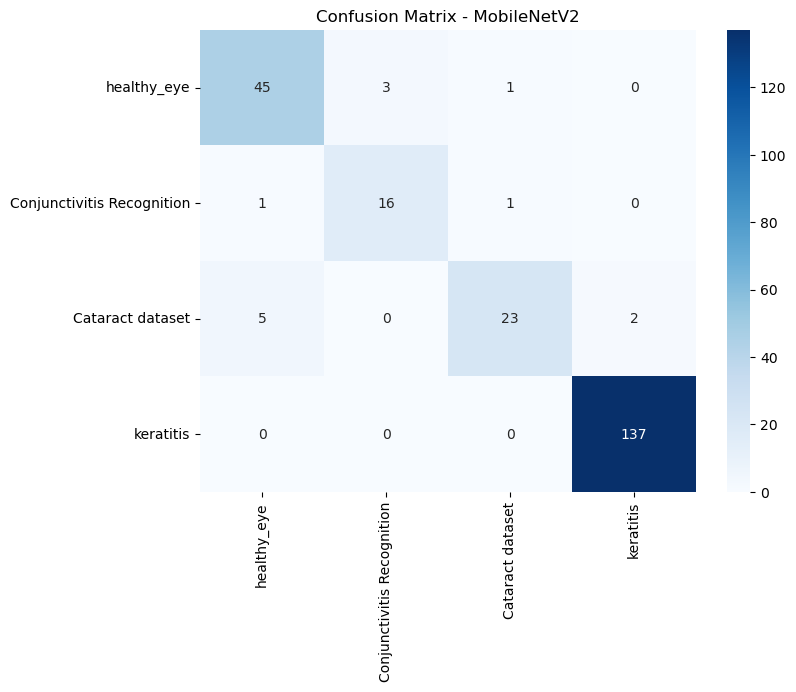

In [9]:
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=datasets))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=datasets, yticklabels=datasets)
plt.title('Confusion Matrix - MobileNetV2')
plt.show()

In [10]:
model.save("eye_disease_mobilenet_balanced.keras")
print("Model saved successfully!")

Model saved successfully!
